In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import numpy as np

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from encoder import Encoder
from mamlnet import MAMLNet
from protonet import ProtoNet
from utils import deterministic, select_fixed_subset, plot_accuracies_all_models
from maml_utils import evaluate_domains_maml
from protonet_utils import evaluate_domains_protonet

In [3]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
experiment_parameters = config["compare_experiments"]
ks = experiment_parameters["ks"]
q = experiment_parameters["q_query"]
n_way = experiment_parameters["n_way"]
episodes = experiment_parameters["episodes"]

accuracies = {"Mnist": [], "Mnist-M": [], "Svhn": []}

data = "Mnist"
test_mnist_images, test_mnist_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Svhn"
test_svhn_images, test_svhn_labels = load_data("test", config[data]["dataset_output_dir"])

test_data = {"Mnist": (test_mnist_images, test_mnist_labels),
             "Mnist-M": (test_mnist_m_images, test_mnist_m_labels),
             "Svhn": (test_svhn_images, test_svhn_labels)}

## ProtoNet

In [5]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["protonet"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]


encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protonet_model = ProtoNet(encoder)
protonet_model.load("../models/weights/protonet.pth", device)


accuracies_protonet = evaluate_domains_protonet(model=protonet_model,test_data=test_data, n_way=n_way,
                              ks=ks, q=q, episodes=episodes, device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_protonet['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_protonet['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_protonet['Svhn'][ks.index(k)]:.4f}")

K=1 Accuracy: Mnist=0.9905, Mnist-M=0.4192, Svhn=0.2493
K=2 Accuracy: Mnist=0.9951, Mnist-M=0.5150, Svhn=0.2764
K=4 Accuracy: Mnist=0.9959, Mnist-M=0.5804, Svhn=0.3114
K=8 Accuracy: Mnist=0.9965, Mnist-M=0.6173, Svhn=0.3403
K=16 Accuracy: Mnist=0.9973, Mnist-M=0.6359, Svhn=0.3554


In [6]:
path = "../results/protonet_accuracies_ks.npy"
np.save(path, accuracies_protonet)

## Maml

In [7]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["maml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
maml_model = MAMLNet(encoder, n_way=n_way, protomaml=False)
maml_model.load("../models/weights/maml.pth", device)

accuracies_maml = evaluate_domains_maml(model=maml_model,test_data=test_data, n_way=n_way, ks=ks, q=q,
                                        episodes=episodes, inner_updates=inner_updates, alpha=alpha,
                                        device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_maml['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_maml['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_maml['Svhn'][ks.index(k)]:.4f}")


K=1 Accuracy: Mnist=0.9525, Mnist-M=0.3441, Svhn=0.2357
K=2 Accuracy: Mnist=0.9727, Mnist-M=0.3967, Svhn=0.2457
K=4 Accuracy: Mnist=0.9785, Mnist-M=0.4487, Svhn=0.2619
K=8 Accuracy: Mnist=0.9812, Mnist-M=0.4823, Svhn=0.2823
K=16 Accuracy: Mnist=0.9809, Mnist-M=0.5124, Svhn=0.2885


In [8]:
path = "../results/maml_accuracies_ks.npy"
np.save(path, accuracies_maml)

## ProtoMAML

In [9]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["protomaml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protomaml_model = MAMLNet(encoder, n_way=n_way, protomaml=True)
protomaml_model.load("../models/weights/protomaml.pth", device)

accuracies_protomaml = evaluate_domains_maml(model=protomaml_model,test_data=test_data, n_way=n_way, ks=ks, q=q,
                                        episodes=episodes, inner_updates=inner_updates, alpha=alpha,
                                        device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_protomaml['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_protomaml['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_protomaml['Svhn'][ks.index(k)]:.4f}")

K=1 Accuracy: Mnist=0.9955, Mnist-M=0.4344, Svhn=0.2519
K=2 Accuracy: Mnist=0.9958, Mnist-M=0.5289, Svhn=0.2873
K=4 Accuracy: Mnist=0.9954, Mnist-M=0.5839, Svhn=0.3135
K=8 Accuracy: Mnist=0.9970, Mnist-M=0.6218, Svhn=0.3447
K=16 Accuracy: Mnist=0.9970, Mnist-M=0.6510, Svhn=0.3629


In [10]:
path = "../results/protomaml_accuracies_ks.npy"
np.save(path, accuracies_protomaml)

## K vs Accuracy

In [11]:
path = "../results/protonet_accuracies_ks.npy"
accuracies_protonet = np.load(path, allow_pickle=True).item()

path = "../results/maml_accuracies_ks.npy"
accuracies_maml = np.load(path, allow_pickle=True).item()

path = "../results/protomaml_accuracies_ks.npy"
accuracies_protomaml = np.load(path, allow_pickle=True).item()

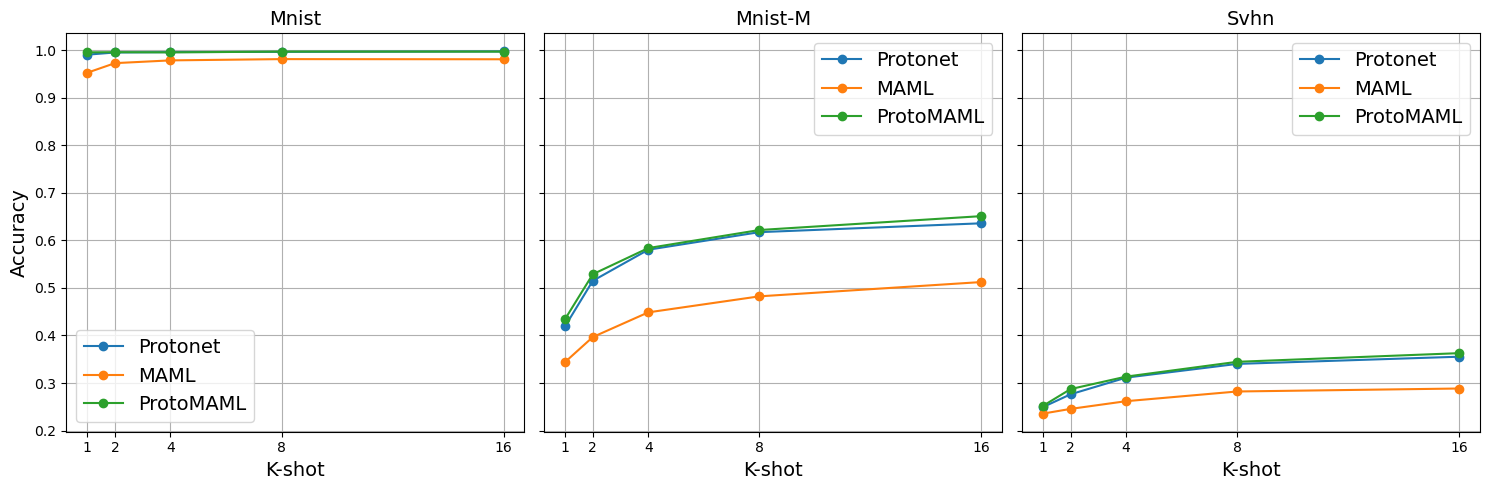

In [12]:
models_names = ["Protonet", "MAML", "ProtoMAML"]
accuracies_all_models = [accuracies_protonet, accuracies_maml, accuracies_protomaml]
plot_accuracies_all_models(ks, accuracies_all_models, models_names)


### TSNES

In [13]:

    #plot 1, class color, domain marker

    # markers = {
    #     "Mnist": "o",
    #     "Mnist-M": "s",
    #     "Svhn": "^"
    # }

    # cmap = plt.cm.get_cmap("tab10", 10)

    # for domain in np.unique(all_domains):
    #     domain_mask = all_domains == domain

    #     ax.scatter(
    #         tsne_embeddings[domain_mask, 0],
    #         tsne_embeddings[domain_mask, 1],
    #         c=all_labels[domain_mask],
    #         cmap=cmap,
    #         vmin=0,
    #         vmax=9,
    #         marker=markers[domain],
    #         alpha=0.7,
    #         s=20,
    #         label=domain
    #     )

    # ax.set_xlabel("t-SNE Dimension 1")
    # ax.set_ylabel("t-SNE Dimension 2")
    # ax.set_title("t-SNE of ProtoNet Embeddings\nColor = class, Marker = domain")
    # ax.grid(True)

    # domain_legend = [
    #     Line2D([0], [0], marker=markers[d], color="w", label=d,
    #         markerfacecolor="gray", markersize=8, linestyle="None")
    #     for d in np.unique(all_domains)
    # ]
    # ax.legend(handles=domain_legend, title="Domain")

    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=9))
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax, ticks=list(range(10)))
    # cbar.set_label("Class")

    # fig.tight_layout()
    # plt.show()



In [14]:
# samples_per_class = 100

# #embeddings
# def get_embeddings_labels(models, fixed_images_labels, device):

#     all_embeddings = []
#     all_labels = []
#     all_domains = []

#     for model in models:
#         model.eval()
#         embeddings_labels = {}

#         with torch.no_grad():
#             for domain in fixed_images_labels:
#                 images, labels = fixed_images_labels[domain]
#                 images = images.to(device)
#                 embeddings = model.encoder(images).cpu().numpy()
#                 labels = labels.cpu().numpy()
#                 embeddings_labels[domain] = (embeddings, labels)

#         all_embeddings_model = []
#         all_labels_model = []
#         all_domains_model = []

#         for domain in embeddings_labels:
#             embeddings, labels = embeddings_labels[domain]
#             all_embeddings_model.append(embeddings)
#             all_labels_model.append(labels)
#             all_domains_model.extend([domain] * len(labels))

#         all_embeddings_model = np.concatenate(all_embeddings_model, axis=0)
#         all_labels_model = np.concatenate(all_labels_model, axis=0)
#         all_domains_model = np.array(all_domains_model)

#         all_embeddings.append(all_embeddings_model)
#         all_labels.append(all_labels_model)
#         all_domains.append(all_domains_model)

#     return all_embeddings, all_labels, all_domains

# def plot_tsnes(models, models_name, test_data, samples_per_class, device):
#     fixed_images_labels = {}

#     for domain in test_data:
#         images, labels = test_data[domain]
#         fixed_images, fixed_labels = select_fixed_subset(
#             images,
#             labels,
#             samples_per_class=samples_per_class,
#             seed=config["xtra"]["seed"]
#         )
#         fixed_images_labels[domain] = (fixed_images, fixed_labels)

    
#     all_embeddings, all_labels, all_domains = get_embeddings_labels(models, fixed_images_labels, device)
    
#     #tsne
#     fig, axes = plt.subplots(len(models), 2, figsize=(20, 20))

#     #subplot 1: domain color
#     domain_colors = {
#         "Mnist": "tab:blue",
#         "Mnist-M": "tab:orange",
#         "Svhn": "tab:green"
#     }

#     cmap = plt.cm.get_cmap("tab10", 10)


#     for i, model in enumerate(models):
#         tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto" )
#         tsne_embeddings = tsne.fit_transform(all_embeddings[i])

#         #plot 2, domain color and class color

#         for domain in np.unique(all_domains[i]):
#             domain_mask = all_domains[i] == domain

#             axes[i][0].scatter(
#                 tsne_embeddings[domain_mask, 0],
#                 tsne_embeddings[domain_mask, 1],
#                 color=domain_colors[domain],
#                 alpha=0.7,
#                 s=20,
#                 label=domain
#             )

#             axes[i][0].set_xlabel("t-SNE Dimension 1")
#             axes[i][0].set_ylabel("t-SNE Dimension 2")
#             axes[i][0].grid(True)
#             axes[i][0].legend(title="Domain")

#             #subplot 2: class color
#             scatter = axes[i][1].scatter(
#                 tsne_embeddings[:, 0],
#                 tsne_embeddings[:, 1],
#                 c=all_labels[i],
#                 cmap=cmap,
#                 vmin=0,
#                 vmax=9,
#                 alpha=0.7,
#                 s=20
#             )

#             axes[i][1].set_xlabel("t-SNE Dimension 1")
#             axes[i][1].set_ylabel("t-SNE Dimension 2")
#             axes[i][1].grid(True)

#         cbar = fig.colorbar(scatter, ax=axes[i][1], ticks=list(range(10)))
#         cbar.set_label("Class")
#         # axes[i].set_title(f"{models_name[i]}")
#         fig.tight_layout()
#     plt.show()

# models = [maml_model, protomaml_model]
# models_name = ["MAML", "ProtoMAML"]
# plot_tsnes(models, models_name, test_data, samples_per_class, device)

3


/tmp/ipykernel_13041/2426477670.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


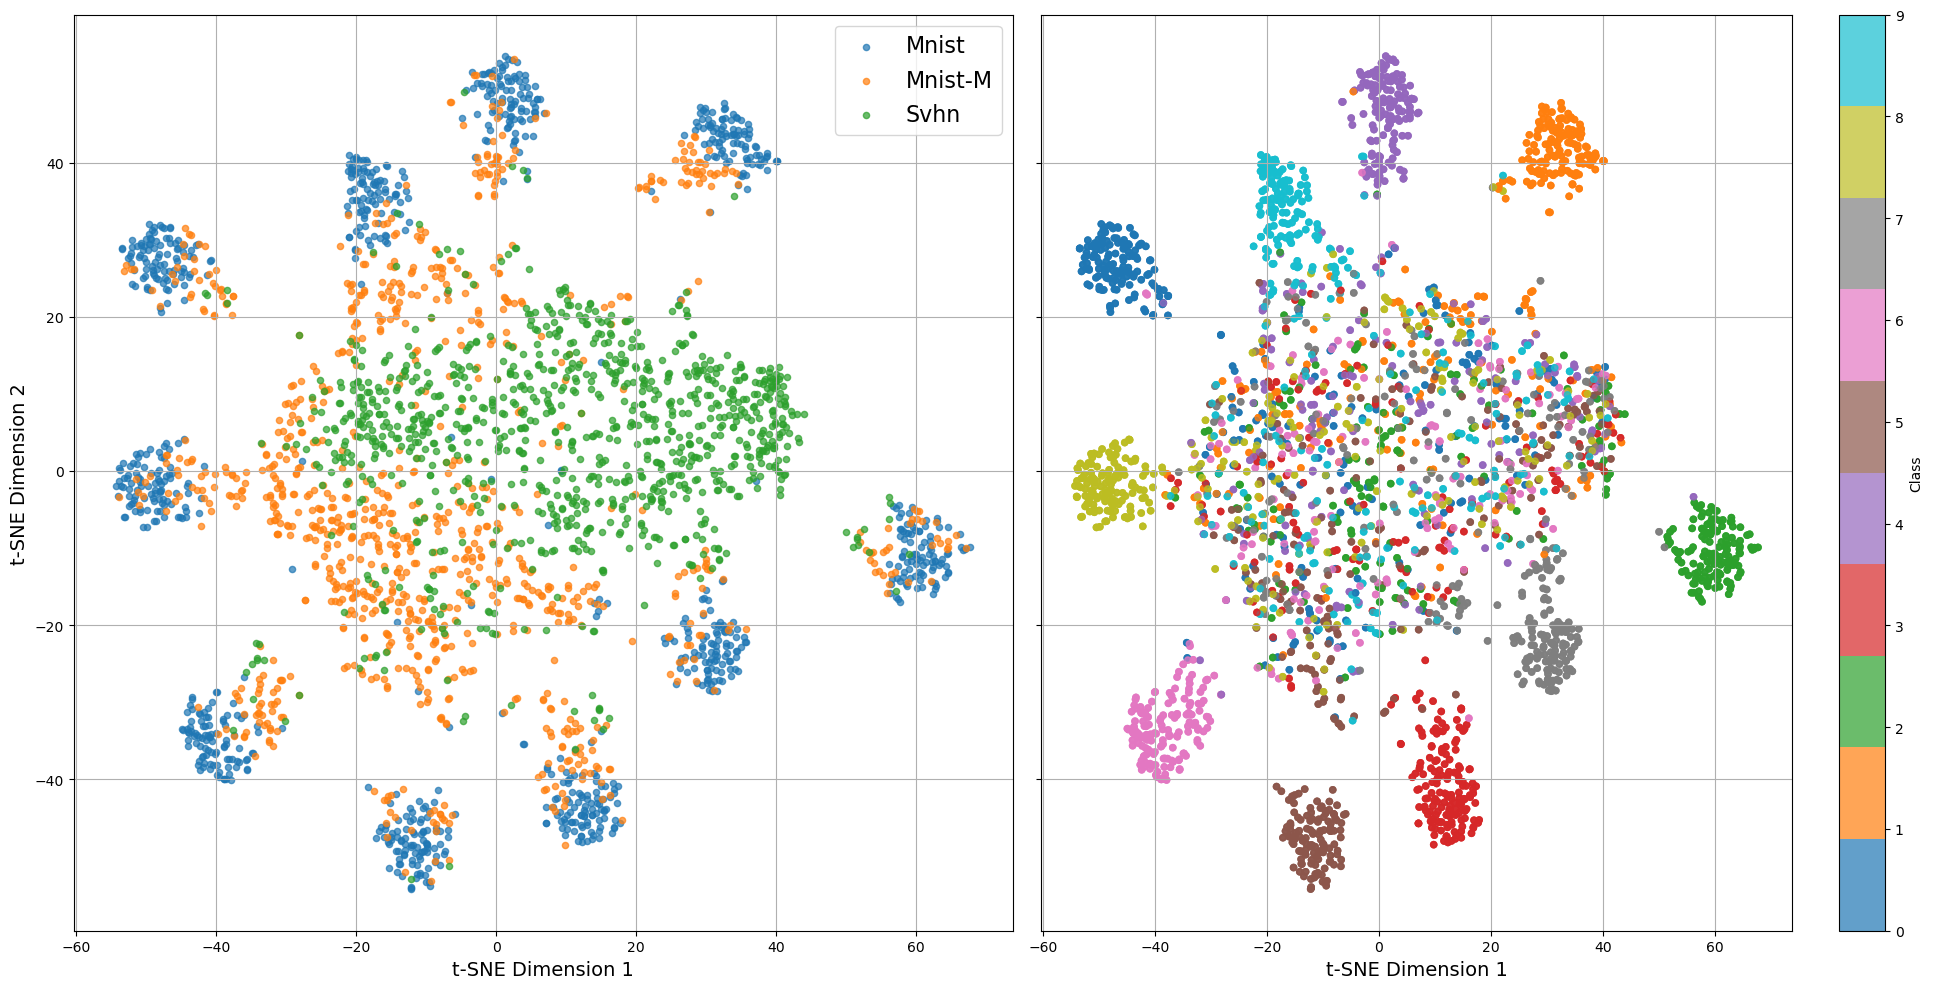

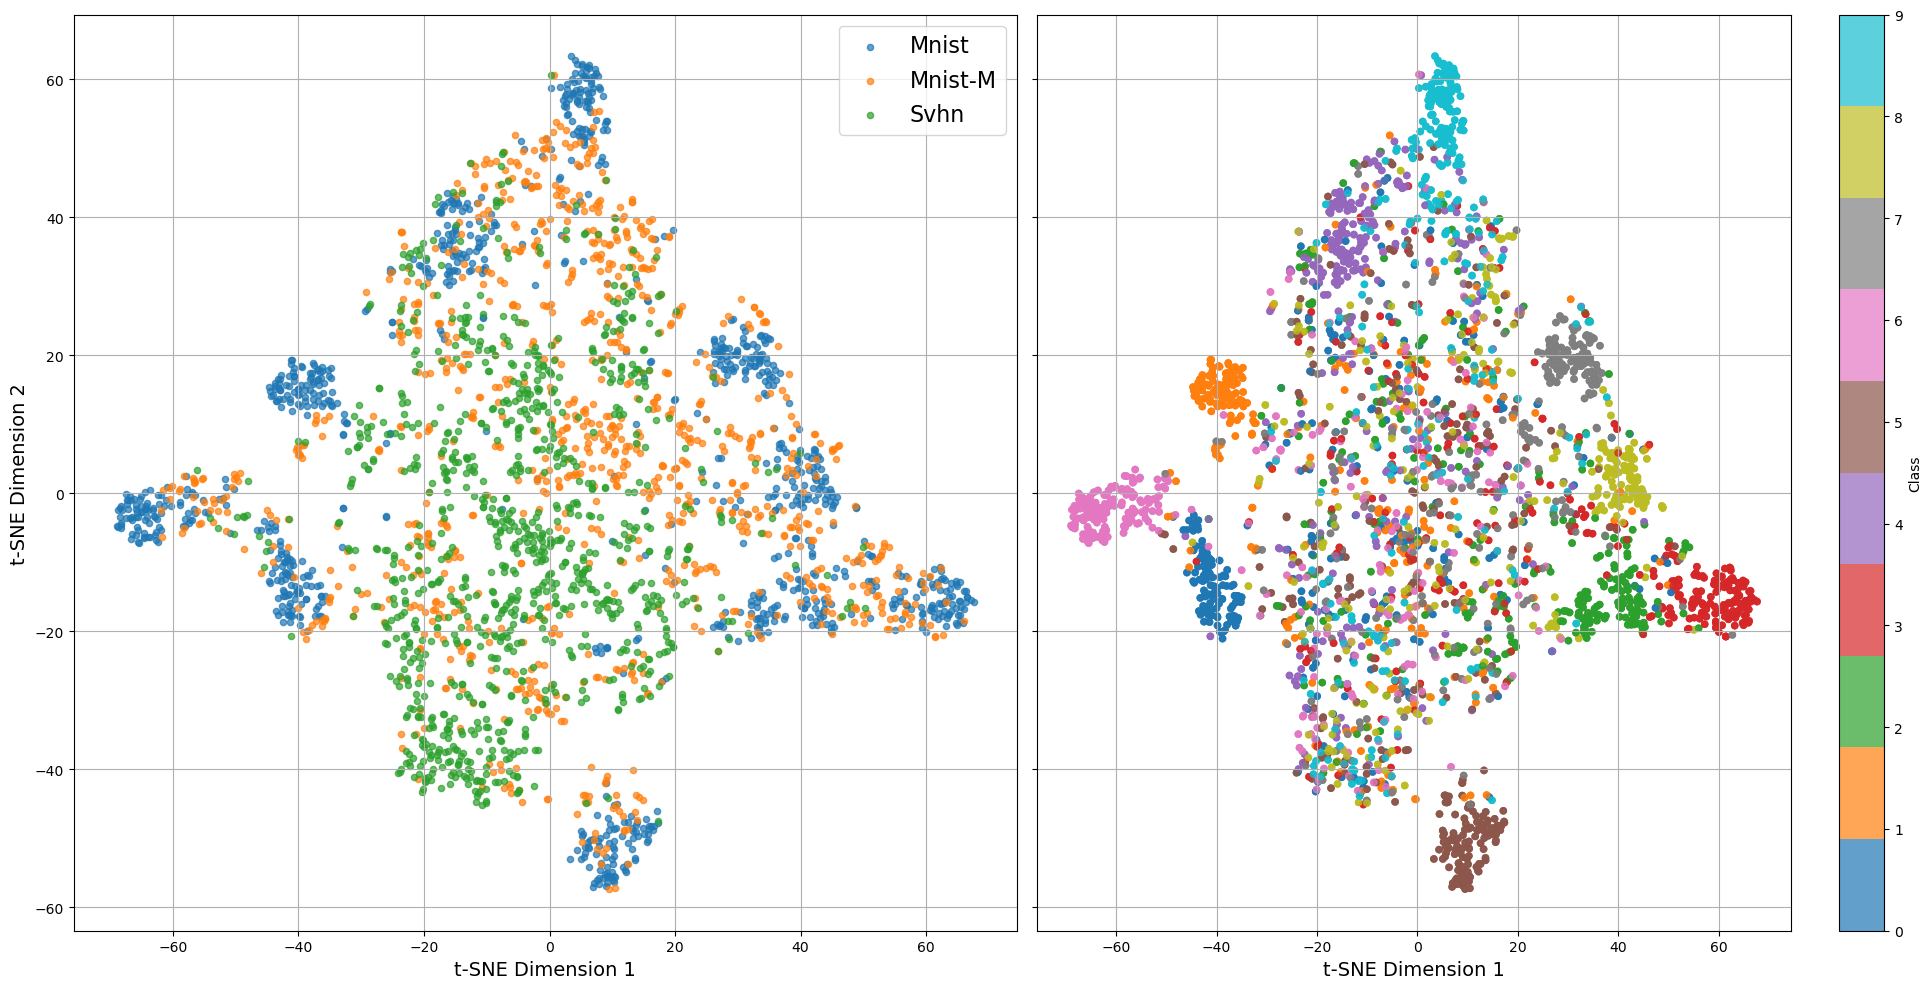

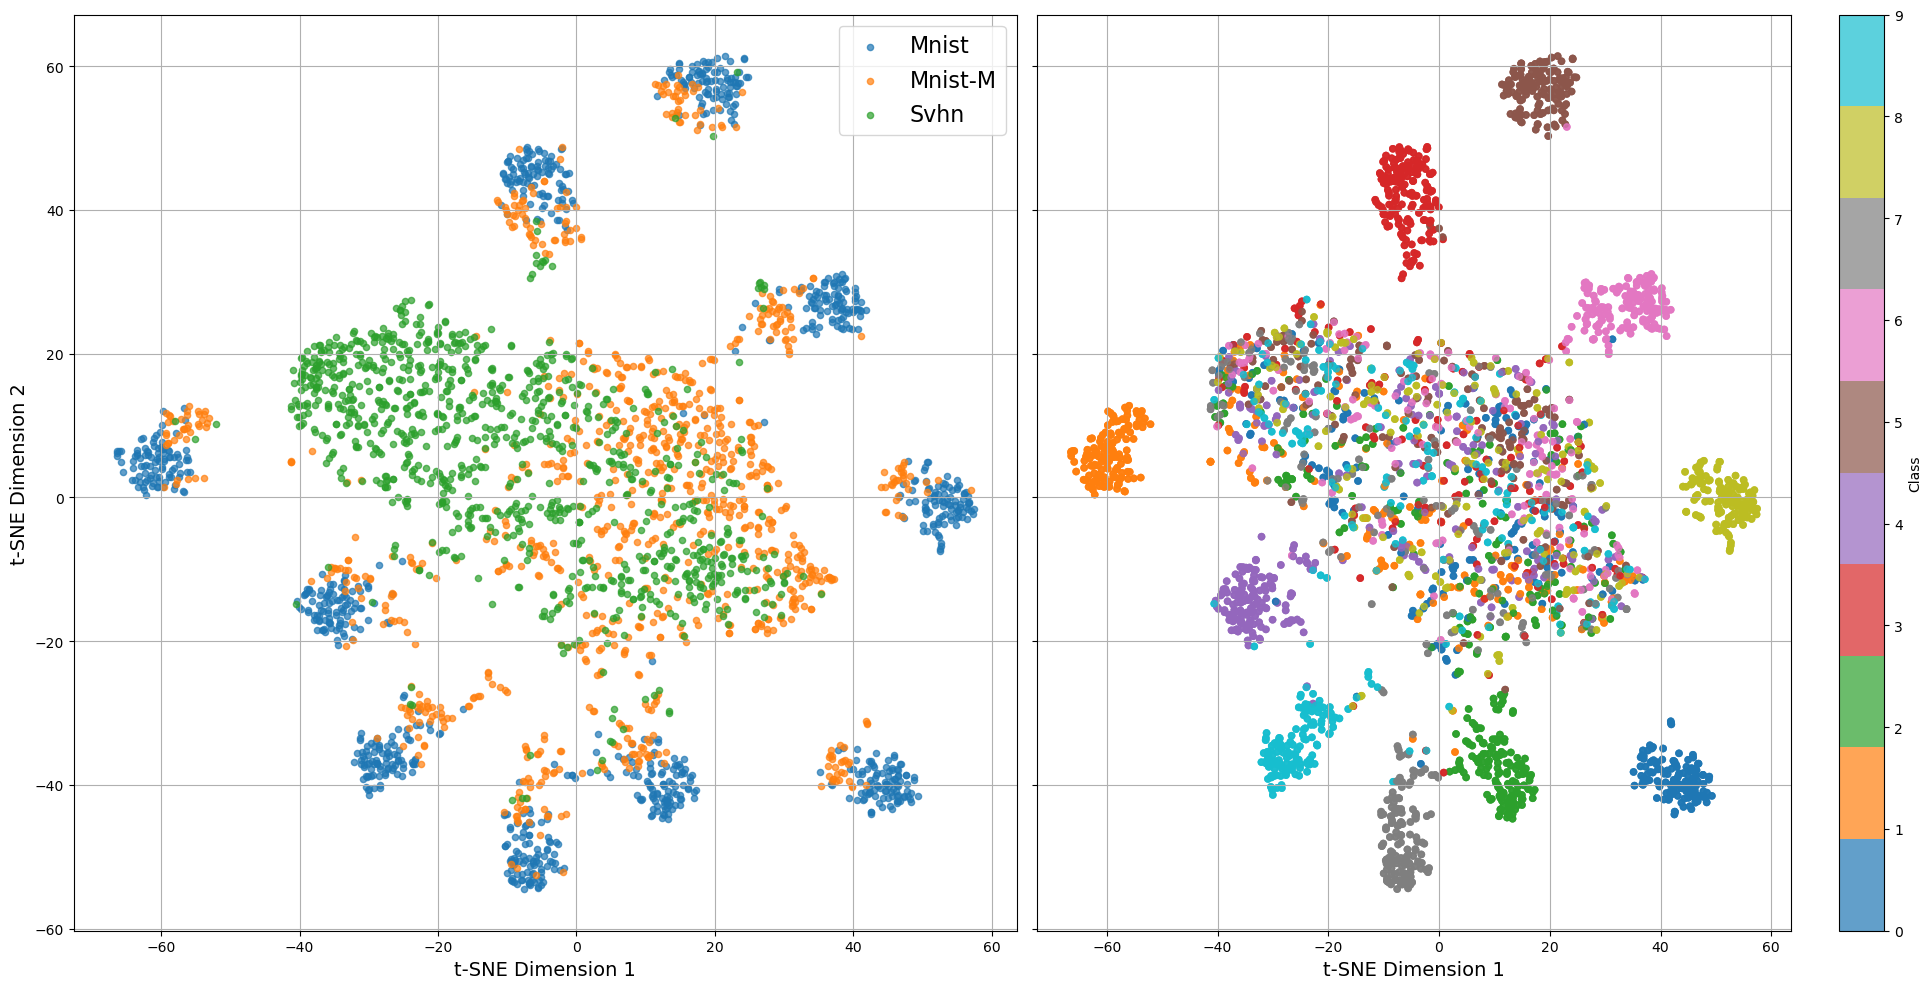

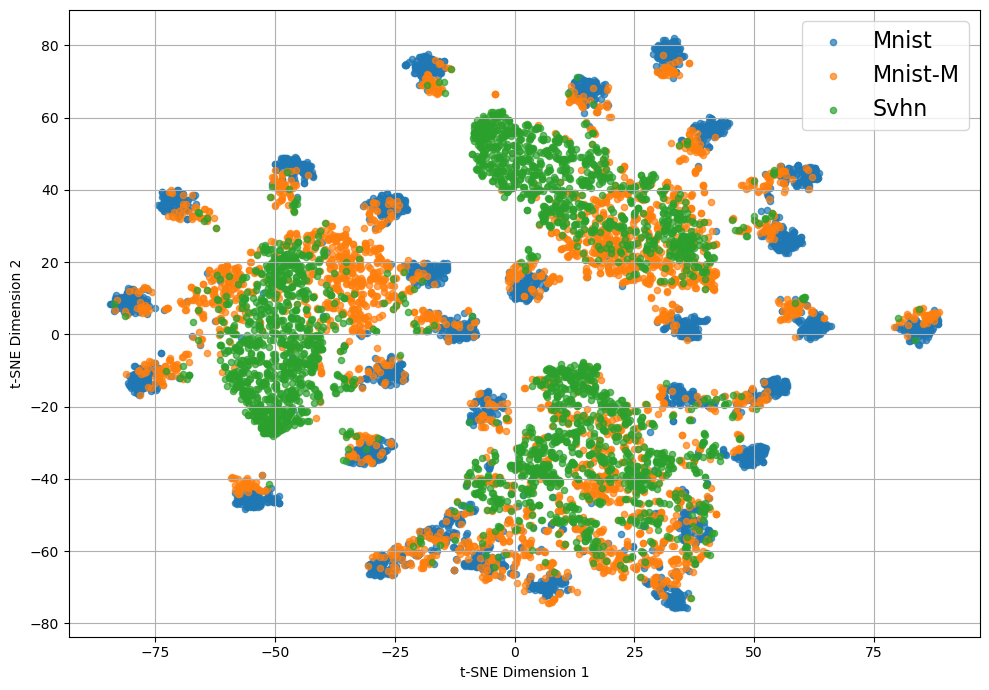

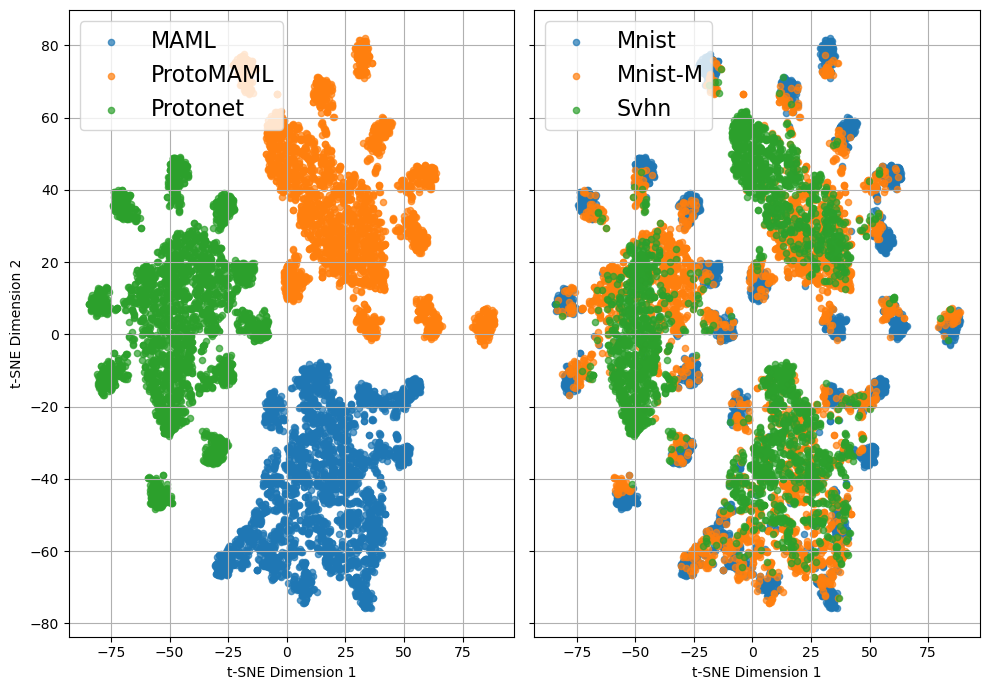

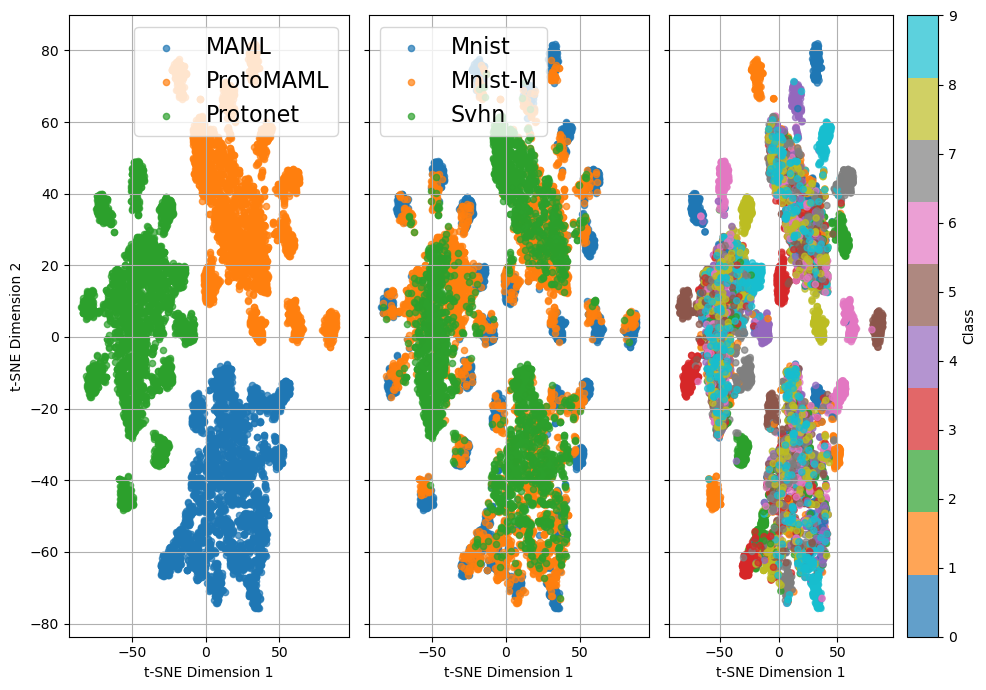

In [15]:
from utils import get_embeddings_labels, plot_tsnes_model

def plot_tsnes(models, models_name, test_data, samples_per_class, device):
    fixed_images_labels = {}

    for domain in test_data:
        images, labels = test_data[domain]
        fixed_images, fixed_labels = select_fixed_subset(
            images,
            labels,
            samples_per_class=samples_per_class,
            seed=config["xtra"]["seed"]
        )
        fixed_images_labels[domain] = (fixed_images, fixed_labels)

    
    all_embeddings, all_labels, all_domains, all_models = get_embeddings_labels(models, models_name, fixed_images_labels, device)
    
    domain_colors = {
        "Mnist": "tab:blue",
        "Mnist-M": "tab:orange",
        "Svhn": "tab:green"
    }

    cmap = plt.cm.get_cmap("tab10", 10)
    path = "../images/temp.png"
    os.makedirs(os.path.dirname(path), exist_ok=True)
    for i, model in enumerate(models):
        plot_tsnes_model(all_embeddings[i], all_labels[i], all_domains[i], domain_colors, cmap, path)

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_domains = np.concatenate(all_domains, axis=0)
    all_models = np.concatenate(all_models, axis=0)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto" )
    tsne_embeddings = tsne.fit_transform(all_embeddings)

    #plot 2
    # subplot 1 model color
    #subplot 2 domain color
    #subplot 3 class color

    model_colors = {
        "Protonet" : "tab:green",
        "MAML": "tab:blue",
        "ProtoMAML": "tab:orange"
    }

    fig, ax = plt.subplots(figsize=(10, 7))

    for domain in np.unique(all_domains):
        domain_mask = all_domains == domain
        ax.scatter(
            tsne_embeddings[domain_mask, 0],
            tsne_embeddings[domain_mask, 1],
            color=domain_colors[domain],
            alpha=0.7,
            s=20,
            label=domain
        )
    
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.grid(True)
    ax.legend(fontsize=16)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharex=True, sharey=True)
    for model_name in np.unique(all_models):
        model_mask = all_models == model_name

        axes[0].scatter(
            tsne_embeddings[model_mask, 0],
            tsne_embeddings[model_mask, 1],
            color=model_colors[model_name],
            alpha=0.7,
            s=20,
            label=model_name
        )
    for domain in np.unique(all_domains):
        domain_mask = all_domains == domain
        axes[1].scatter(
            tsne_embeddings[domain_mask, 0],
            tsne_embeddings[domain_mask, 1],
            color=domain_colors[domain],
            alpha=0.7,
            s=20,
            label=domain
        )
    
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    axes[0].grid(True)
    axes[0].legend(fontsize=16)

    axes[1].set_xlabel("t-SNE Dimension 1")
    axes[1].grid(True)
    axes[1].legend(fontsize=16)
    fig.tight_layout()
    plt.show()


    fig, axes = plt.subplots(1, 3, figsize=(10, 7), sharex=True, sharey=True)
    for model_name in np.unique(all_models):
        model_mask = all_models == model_name

        axes[0].scatter(
            tsne_embeddings[model_mask, 0],
            tsne_embeddings[model_mask, 1],
            color=model_colors[model_name],
            alpha=0.7,
            s=20,
            label=model_name
        )
    for domain in np.unique(all_domains):
        domain_mask = all_domains == domain
        axes[1].scatter(
            tsne_embeddings[domain_mask, 0],
            tsne_embeddings[domain_mask, 1],
            color=domain_colors[domain],
            alpha=0.7,
            s=20,
            label=domain
        )

    scatter = axes[2].scatter(
        tsne_embeddings[:, 0],
        tsne_embeddings[:, 1],
        c=all_labels,
        cmap=cmap,
        vmin=0,
        vmax=9,
        alpha=0.7,
        s=20,
    )
    
    axes[0].set_xlabel("t-SNE Dimension 1")
    axes[0].set_ylabel("t-SNE Dimension 2")
    axes[0].grid(True)
    axes[0].legend(fontsize=16)

    axes[1].set_xlabel("t-SNE Dimension 1")
    axes[1].grid(True)
    axes[1].legend(fontsize=16)

    axes[2].set_xlabel("t-SNE Dimension 1")
    axes[2].grid(True)

    cbar = fig.colorbar(scatter, ax=axes[2], ticks=list(range(10)))
    cbar.set_label("Class")
    fig.tight_layout()
    plt.show()

models = [protonet_model, maml_model, protomaml_model]
models_name = ["Protonet", "MAML", "ProtoMAML"]
samples_per_class = 100
plot_tsnes(models, models_name, test_data, samples_per_class, device)